<a href="https://colab.research.google.com/github/cksumalinog/software-engineering-models/blob/main/Phase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading dataset from GitHub...
Cleaning data...
Generating EDA visualizations...


/tmp/ipykernel_8727/4094096169.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='survived', palette='viridis')


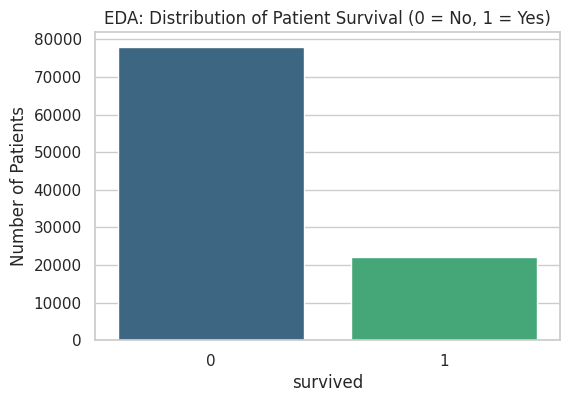

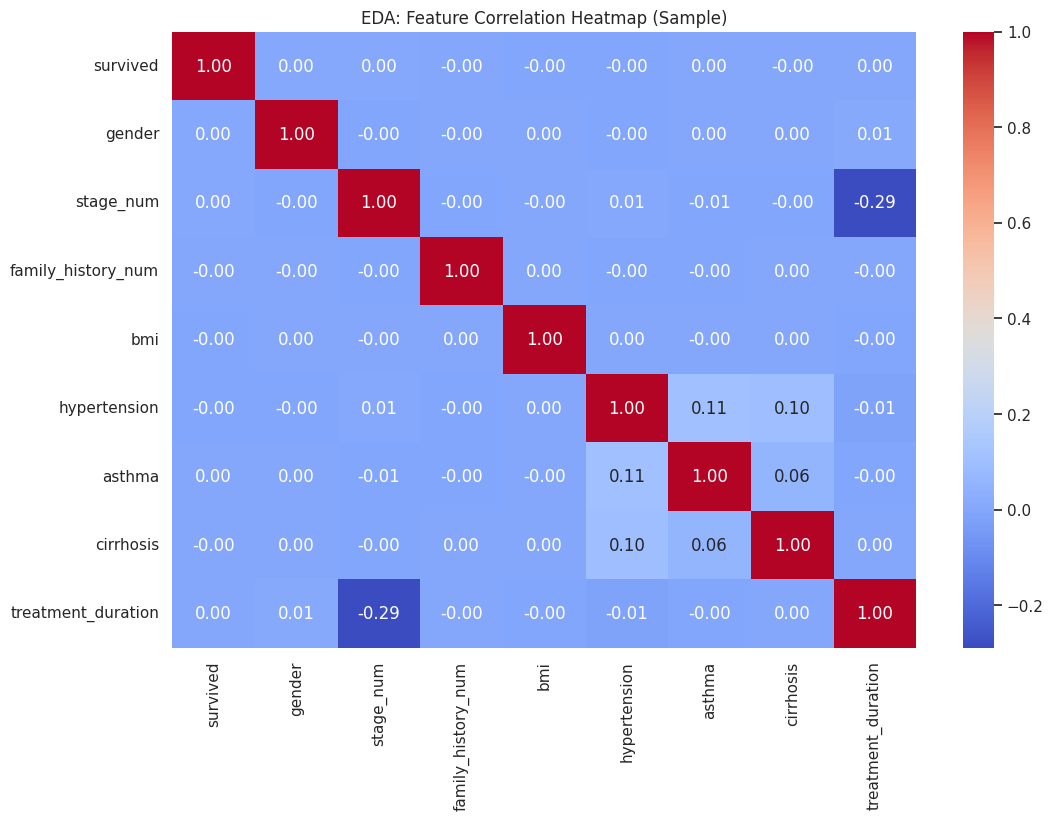

Splitting data and training the Random Forest Model...
Model trained successfully!
Generating model evaluation charts...


/tmp/ipykernel_8727/4094096169.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


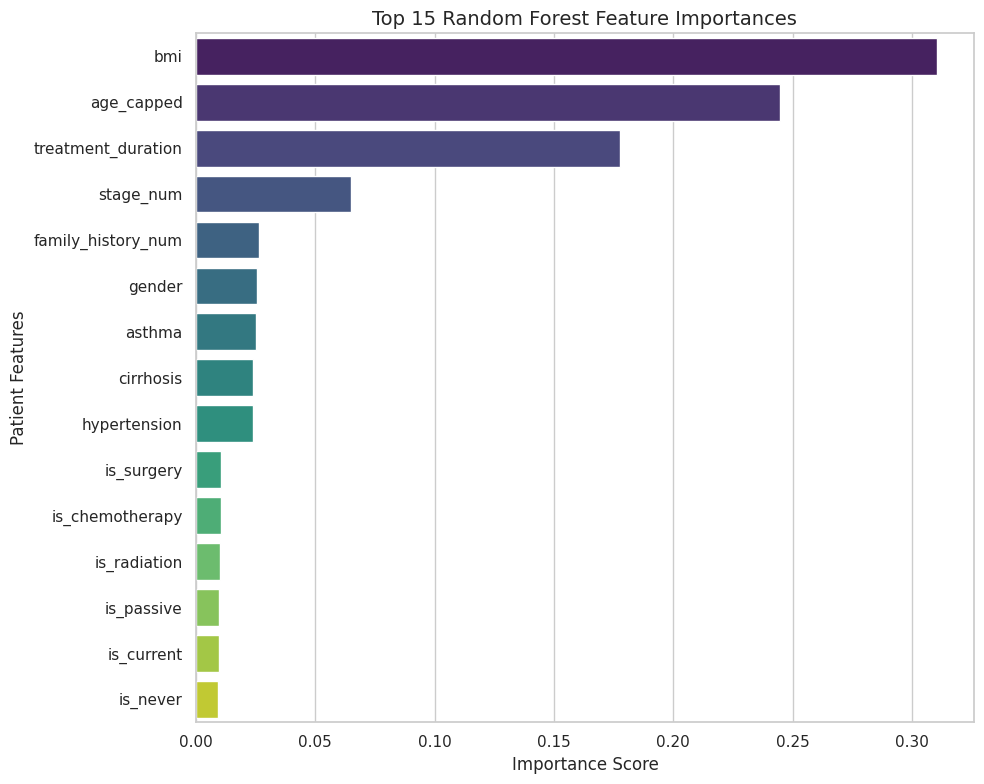

/tmp/ipykernel_8727/4094096169.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_test, y=y_pred_probs, palette='Set2')


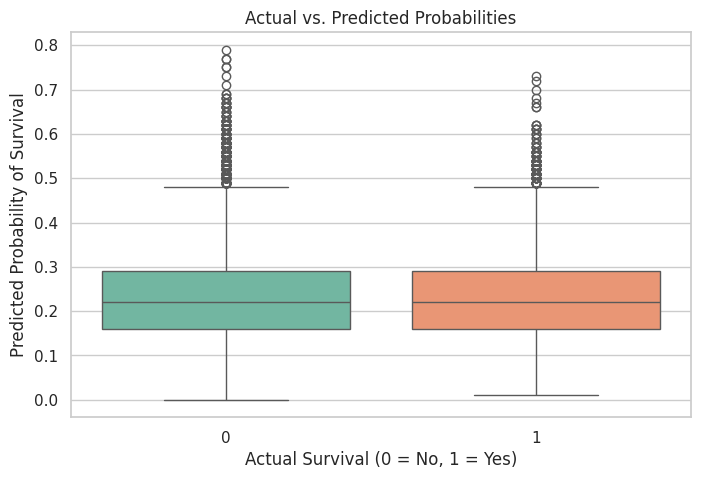

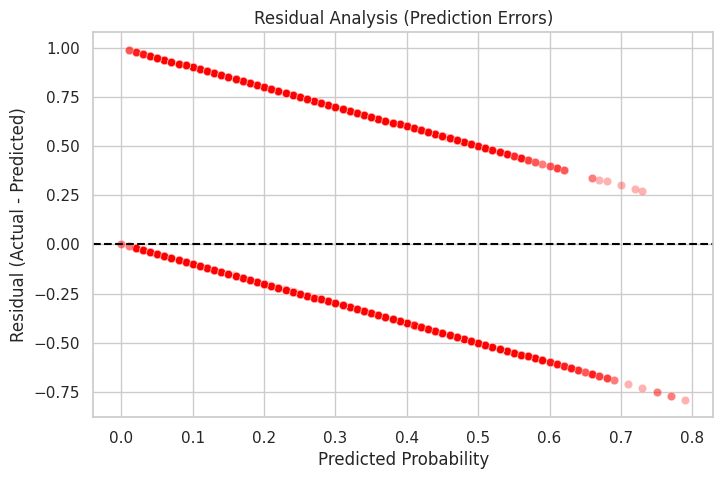

<Figure size 600x600 with 0 Axes>

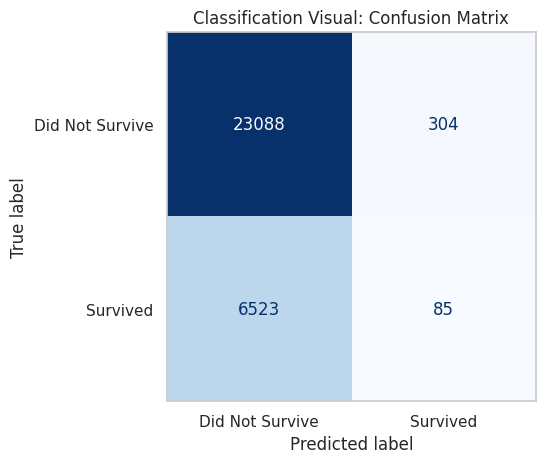

All tasks completed successfully!


In [1]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

# Set visual style for all charts
sns.set_theme(style="whitegrid")

# ==========================================
# 2. LOAD & PREPROCESS DATA
# ==========================================
print("Loading dataset from GitHub...")
url = "https://raw.githubusercontent.com/cksumalinog/software-engineering-phase-4/refs/heads/main/Lung%20Cancer(100k)(Classification).csv"
df = pd.read_csv(url)

print("Cleaning data...")
# Drop missing values to prevent model crashes
df = df.dropna()

# Convert any text columns (like "Male"/"Female") into numeric 1s and 0s
df = pd.get_dummies(df, drop_first=True)

# ==========================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("Generating EDA visualizations...")

# A. Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='survived', palette='viridis')
plt.title('EDA: Distribution of Patient Survival (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()

# B. Correlation Heatmap
plt.figure(figsize=(12, 8))
# Safely grabbing a subset of numeric columns to keep the heatmap readable
# We grab 'survived' and the first 8 features
cols_to_plot = ['survived'] + [col for col in df.columns if col != 'survived'][:8]
sns.heatmap(df[cols_to_plot].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('EDA: Feature Correlation Heatmap (Sample)')
plt.show()

# ==========================================
# 4. MODEL TRAINING
# ==========================================
print("Splitting data and training the Random Forest Model...")
X = df.drop('survived', axis=1)
y = df['survived']

# Split the data (stratify ensures balanced survival classes in train/test sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Model trained successfully!")

# ==========================================
# 5. EVALUATION VISUALIZATIONS
# ==========================================
print("Generating model evaluation charts...")

# A. Feature Importance Chart
importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Patient Features': feature_names,
    'Importance Score': importances
}).sort_values(by='Importance Score', ascending=False)

plt.figure(figsize=(10, 8))
# We plot the top 15 features so the chart doesn't get squished
sns.barplot(
    data=feature_importance_df.head(15),
    x='Importance Score',
    y='Patient Features',
    palette='viridis'
)
plt.title('Top 15 Random Forest Feature Importances', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Patient Features', fontsize=12)
plt.tight_layout()
plt.show()

# B. Actual vs Predicted Probabilities
y_pred_probs = rf_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))
sns.boxplot(x=y_test, y=y_pred_probs, palette='Set2')
plt.title('Actual vs. Predicted Probabilities')
plt.xlabel('Actual Survival (0 = No, 1 = Yes)')
plt.ylabel('Predicted Probability of Survival')
plt.show()

# C. Residual Analysis
residuals = y_test - y_pred_probs
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_probs, y=residuals, alpha=0.3, color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Analysis (Prediction Errors)')
plt.xlabel('Predicted Probability')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()

# D. Confusion Matrix
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test, y_test,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues',
    colorbar=False
)
plt.title('Classification Visual: Confusion Matrix')
plt.grid(False)
plt.show()

print("All tasks completed successfully!")